In [4]:
import pandas as pd
import numpy as np 

In [5]:
df = pd.read_csv('../Datasets/placement.csv')

In [6]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [7]:
df = df.iloc[:, 1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
# ==========================================================
# Machine Learning Workflow
# ==========================================================

# 0. Preprocessing + EDA + Feature Selection
# 1. Extract input and output columns
# 2. Scale the values (if required)
# 3. Train-Test Split
# 4. Train the model
# 5. Evaluate the model / Model Selection
# 6. Deploy the model

In [10]:
import matplotlib.pyplot as plt

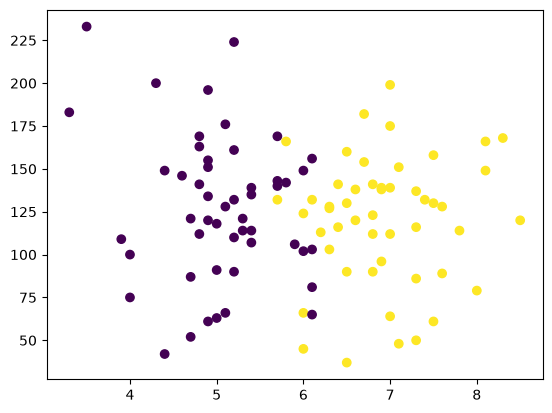

In [11]:
plt.scatter(df["cgpa"], df["iq"], c=df["placement"])

In [12]:
X = df.iloc[:, 0:2]
Y = df.iloc[:, -1]

In [13]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1)

X_train


,cgpa,iq
84,5.7,169.0
64,7.0,64.0
69,8.5,120.0
27,6.0,124.0
61,7.3,137.0
...,...,...
83,7.5,130.0
17,3.3,183.0
87,5.7,132.0
24,4.7,121.0


In [16]:
Y_test

38    1
37    1
81    0
22    0
41    0
36    0
51    0
31    0
6     0
11    1
Name: placement, dtype: int64

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[-0.28183655,  1.12033644],
       [ 0.86312444, -1.41673027],
       [ 2.18423327, -0.06362802],
       [-0.01761478,  0.03302214],
       [ 1.12734621,  0.34713516],
       [ 0.51082875,  0.3712977 ],
       [ 0.24660698,  0.10550976],
       [ 0.24660698, -0.4743912 ],
       [-0.01761478, -1.36840519],
       [ 0.07045914,  0.80622342],
       [ 1.12734621, -1.75500583],
       [ 0.15853306, -0.2327658 ],
       [-0.19376263,  0.46794786],
       [-0.01761478, -0.49855374],
       [-1.42679754, -1.94830615],
       [ 0.3346809 ,  0.44378532],
       [ 0.42275483, -2.06911885],
       [ 0.86312444,  1.26531168],
       [ 0.42275483, -0.78850423],
       [-0.63413224, -0.20860326],
       [ 0.68697659,  0.44378532],
       [ 0.59890267,  1.43444946],
       [ 0.59890267,  0.75789834],
       [ 0.24660698,  0.1296723 ],
       [-1.51487146,  1.86937519],
       [ 0.07045914, -1.39256773],
       [ 0.86312444,  1.84521265],
       [-2.21946284,  2.66673901],
       [-0.98642793,

In [18]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.42275483,  0.90287358],
       [ 1.83193758,  0.63708564],
       [-0.54605832, -0.37774104],
       [-0.98642793, -0.06362802],
       [-0.54605832, -0.20860326],
       [-0.28183655,  0.41962278],
       [-1.07450185,  0.44378532],
       [-1.86716715, -0.32941596],
       [-0.28183655,  0.4921104 ],
       [ 0.77505052,  0.3712977 ]])

In [19]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

#model training
clf.fit(X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
Y_pred=clf.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

In [23]:
accuracy_score(Y_test, Y_pred)

1.0

<Axes: >

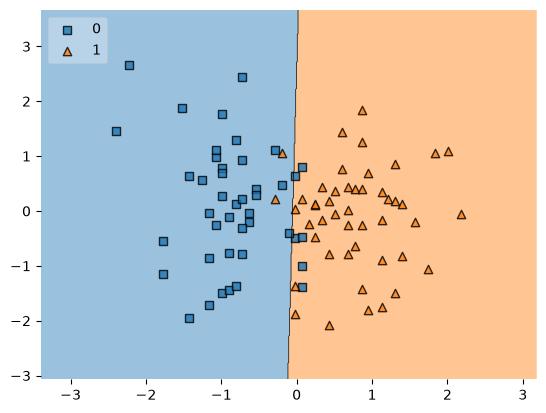

In [27]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, Y_train.values, clf=clf, legend= 2)

In [28]:
import pickle

In [ ]:
pickle.dump(clf, open('model.pkl', 'wb'))
#returns a model and saves locally